# Pure Sitka spruce dataset comparison

This notebook compares the current cleaned modelling dataset, built from the majority-Sitka-spruce workflow, against the new `scpt100` pure-Sitka-spruce stand layer in this legacy folder.

The aim is not to switch datasets automatically. The aim is to quantify how dramatic the change would be if the model cohort were restricted to stands present in the pure-SS layer.

Questions answered here:

- How many cleaned plot-year rows and distinct plots would remain?
- Which survey years are most affected?
- Which compartments/sub-compartments disagree between the current cleaned data and the pure-SS layer?
- Do key variables (`Age`, `Top_Height99`, `CanopyCover`, `yldc`) shift materially?
- Where are retained vs dropped plots located spatially for each survey year?

This notebook is deliberately contained in `legacy/pure_SS_dataset/` and does not write files.

In [1]:
import struct
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

PURE_DIR = project_root / "legacy" / "pure_SS_dataset"
PURE_DBF = PURE_DIR / "scpt100 (1)" / "scpt100.dbf"
PURE_SHP = PURE_DIR / "scpt100 (1)" / "scpt100.shp"

MASTER_4_PATH = project_root / "data" / "processed" / "master" / "clean_master_4survey.parquet"
MASTER_6_PATH = project_root / "data" / "processed" / "master" / "clean_master_6survey.parquet"
COORDS_PATH = project_root / "data" / "interim" / "plot_coordinates.csv.gz"

print("project_root:", project_root)
print("pure DBF exists:", PURE_DBF.exists())
print("pure SHP exists:", PURE_SHP.exists())

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss
pure DBF exists: True
pure SHP exists: True


## Load the pure-SS layer attributes

The `scpt100` layer is a shapefile. If `geopandas` works on your machine, you can inspect geometry too, but the comparison below only needs the DBF attributes and is therefore robust to shapefile/GDAL reader issues.

Important assumption: this layer is treated as the pure-Sitka-spruce authority because that is how it was supplied/named. The `spis` column in the DBF is not used as a filter here because it appears blank in the raw records.

In [2]:
def read_dbf(path):
    """Small DBF reader for attribute comparison; avoids relying on GDAL for this audit."""
    path = Path(path)
    raw_bytes = path.read_bytes()
    n_records = struct.unpack("<I", raw_bytes[4:8])[0]
    header_len = struct.unpack("<H", raw_bytes[8:10])[0]
    record_len = struct.unpack("<H", raw_bytes[10:12])[0]

    fields = []
    pos = 32
    while raw_bytes[pos] != 0x0D:
        desc = raw_bytes[pos:pos + 32]
        name = desc[:11].split(b"\x00", 1)[0].decode("ascii", errors="replace")
        field_type = chr(desc[11])
        field_len = desc[16]
        decimals = desc[17]
        fields.append((name, field_type, field_len, decimals))
        pos += 32

    records = []
    for i in range(n_records):
        record = raw_bytes[header_len + i * record_len: header_len + (i + 1) * record_len]
        if not record or record[0:1] == b"*":
            continue
        offset = 1
        values = {}
        for name, field_type, field_len, decimals in fields:
            value = record[offset:offset + field_len].decode("latin1", errors="replace").strip()
            if value == "":
                parsed = np.nan
            elif field_type in {"N", "F"}:
                parsed = float(value) if decimals else int(float(value))
            elif field_type == "D" and len(value) == 8:
                parsed = pd.to_datetime(value, format="%Y%m%d", errors="coerce")
            else:
                parsed = value
            values[name] = parsed
            offset += field_len
        records.append(values)
    return pd.DataFrame(records)


def add_stand_key(df):
    out = df.copy()
    for col in ["blk", "cpmt"]:
        out[col] = pd.to_numeric(out[col], errors="coerce").astype("Int64")
    out["scpt"] = out["scpt"].astype("string").str.strip().str.upper()
    out["stand_key"] = (
        out["blk"].astype("string") + "_"
        + out["cpmt"].astype("string") + "_"
        + out["scpt"].fillna("")
    )
    return out

pure_stands = add_stand_key(read_dbf(PURE_DBF))
pure_keys = set(pure_stands["stand_key"].dropna())

print(f"Pure-SS stand records: {len(pure_stands):,}")
print(f"Distinct pure-SS stand keys: {pure_stands['stand_key'].nunique():,}")
print(f"Distinct compartments: {pure_stands['cpmt'].nunique():,}")
print(f"Distinct blocks: {pure_stands['blk'].nunique():,}")

pure_stands.head()

Pure-SS stand records: 1,279
Distinct pure-SS stand keys: 1,279
Distinct compartments: 443
Distinct blocks: 18


,blk,cpmt,scpt,cult,forest,global_id,display_id,cots_distr,cots_count,rel_fw_gui,fw_guid,luse,habt_code,spis,plyr,yldc,whcl,fw_contact,create_dat,fw_conta_1,modified_d,fcst,next_thin_,selection_,template_g,last_thinn,previously,thcy,maxmaifell,template_n,flmth,flyr,comp_maxma,Shape_Leng,Shape_Area,stand_key
0,31,2308,C,10,701,{C6A1801E-185F-4A02-BDD5-978BE03C6806},701 31 2308 C,701,500,{D7EF56B4-4945-4E29-B4C0-FF4A86D3D5C3},{D6D14DAB-1334-4BFC-ADB8-BD402F36A4B0},FRC,NBNSYS0000004556,NaN,0,0,0,NaN,NaT,FORESTRY\gail.odonnell,2020-09-07,N,0,NaN,NaN,0,NaN,0,0,NaN,0,0,0,556.288716,6553.963118,31_2308_C
1,60,4012,E,10,701,{CACA2422-8BE5-4F0D-9F14-901343077399},701 60 4012 E,701,500,{EE9AE1FF-AEC6-4516-877D-B7BD26AA72EA},{8DDC4E44-4F0E-4625-A8C5-B0D14D28DEE5},FRC,NBNSYS0000004556,NaN,0,0,3,NaN,NaT,FORESTRY\gail.odonnell,2025-10-08,N,0,NaN,NaN,0,NaN,0,0,NaN,0,0,0,523.611736,12553.629737,60_4012_E
2,21,1120,D,10,701,{CFF5ADD5-F485-4E78-A65B-10C27B2E5B50},701 21 1120 D,701,500,{0E52407E-49FB-44DA-BC93-4162A8AB2239},{CD080758-685F-4682-8C3E-B0F04EA0179E},FMQ,NBNSYS0000000001,NaN,0,0,4,NaN,NaT,FORESTRY\gail.odonnell,2025-10-13,N,0,NaN,NaN,0,NaN,5,0,NaN,0,0,0,247.896726,3474.893885,21_1120_D
3,21,1111,C,10,701,{FFB47E91-D21F-4A06-8BF7-7314DF4CDD38},701 21 1111 C,701,500,{0AED0318-0471-494B-9F35-8EE04E7BEF08},{FDC5631E-154C-4928-A6F0-B1F6246D64B6},PHF,NBNSYS0000004541,SS,2010,12,3,NaN,NaT,FORESTRY\gail.odonnell,2025-10-31,F,2026,6,{68307BB7-3718-470C-A46F-36744281A52F},0,0,0,0,C&T No Thin,0,0,0,2999.486079,47745.203048,21_1111_C
4,21,1118,K,10,701,{2A7ED76C-90FE-43CA-8497-463B7A3D77C4},701 21 1118 K,701,500,{9A6A4C66-D34D-43FE-A30A-117C4BB9266E},{653246F8-C0F0-4F1C-845C-8DFC7E36C323},PFE,NBNSYS0000004541,NaN,0,0,4,NaN,NaT,FORESTRY\gail.odonnell,2025-10-14,N,0,NaN,NaN,0,NaN,0,0,NaN,0,2019,0,491.128142,8190.102897,21_1118_K


In [3]:
pure_summary = pd.DataFrame({
    "column": pure_stands.columns,
    "non_null": [pure_stands[c].notna().sum() for c in pure_stands.columns],
    "distinct": [pure_stands[c].nunique(dropna=True) for c in pure_stands.columns],
    "example_values": [pure_stands[c].dropna().astype(str).head(5).tolist() for c in pure_stands.columns],
})
pure_summary

,column,non_null,distinct,example_values
0,blk,1279,18,"[31, 60, 21, 21, 21]"
1,cpmt,1279,443,"[2308, 4012, 1120, 1111, 1118]"
2,scpt,1279,26,"[C, E, D, C, K]"
3,cult,1275,8,"[10, 10, 10, 10, 10]"
4,forest,1279,2,"[701, 701, 701, 701, 701]"
5,global_id,1279,1279,"[{C6A1801E-185F-4A02-BDD5-978BE03C6806}, {CACA..."
6,display_id,1279,1279,"[701 31 2308 C, 701 60 4012 E, 701 21 1120 D, ..."
7,cots_distr,1279,1,"[701, 701, 701, 701, 701]"
8,cots_count,1279,1,"[500, 500, 500, 500, 500]"
9,rel_fw_gui,1279,444,"[{D7EF56B4-4945-4E29-B4C0-FF4A86D3D5C3}, {EE9A..."


## Load the current cleaned datasets

These are the existing cleaned master exports from your current workflow. They are already filtered/balanced according to the dissertation cleaning notebook, including the current Sitka spruce filter based on `spis == "SS"`.

In [4]:
master_4 = add_stand_key(pd.read_parquet(MASTER_4_PATH))
master_6 = add_stand_key(pd.read_parquet(MASTER_6_PATH))
coords = pd.read_csv(COORDS_PATH)

for name, df in [("4survey", master_4), ("6survey", master_6)]:
    print(f"{name}: {len(df):,} rows, {df['identification'].nunique():,} plots, {df['stand_key'].nunique():,} stand keys")
    print("  years:", sorted(df["LiDAR_year"].unique()))
    print("  spis values:", df["spis"].value_counts(dropna=False).to_dict())

4survey: 287,064 rows, 71,766 plots, 829 stand keys
  years: [np.int32(2008), np.int32(2012), np.int32(2021), np.int32(2023)]
  spis values: {'SS': 287064}
6survey: 83,382 rows, 13,897 plots, 152 stand keys
  years: [np.int32(2002), np.int32(2006), np.int32(2008), np.int32(2012), np.int32(2021), np.int32(2023)]
  spis values: {'SS': 83382}


## Apply a pure-SS stand-key restriction

This is the direct "what would change?" test: keep the current cleaned plot-year rows only when their `(blk, cpmt, scpt)` stand key appears in the pure-SS layer.

This does not rebuild the whole original cleaning pipeline from the raw GPKG. It compares the already-cleaned current modelling cohort to the stricter pure-SS stand definition.

In [5]:
def cohort_retention_summary(df, cohort_name):
    flagged = df.copy()
    flagged["in_pure_ss_layer"] = flagged["stand_key"].isin(pure_keys)

    rows = []
    for year, group in flagged.groupby("LiDAR_year", sort=True):
        kept = group[group["in_pure_ss_layer"]]
        rows.append({
            "cohort": cohort_name,
            "LiDAR_year": year,
            "current_rows": len(group),
            "pure_ss_rows": len(kept),
            "rows_retained_pct": 100 * len(kept) / len(group),
            "current_plots": group["identification"].nunique(),
            "pure_ss_plots": kept["identification"].nunique(),
            "plots_retained_pct": 100 * kept["identification"].nunique() / group["identification"].nunique(),
            "current_stands": group["stand_key"].nunique(),
            "pure_ss_stands": kept["stand_key"].nunique(),
            "stands_retained_pct": 100 * kept["stand_key"].nunique() / group["stand_key"].nunique(),
        })
    return flagged, pd.DataFrame(rows)

master_4_flagged, retention_4 = cohort_retention_summary(master_4, "4survey")
master_6_flagged, retention_6 = cohort_retention_summary(master_6, "6survey")
retention = pd.concat([retention_4, retention_6], ignore_index=True)

retention

,cohort,LiDAR_year,current_rows,pure_ss_rows,rows_retained_pct,current_plots,pure_ss_plots,plots_retained_pct,current_stands,pure_ss_stands,stands_retained_pct
0,4survey,2008,71766,17278,24.075467,71766,17278,24.075467,829,249,30.036188
1,4survey,2012,71766,17278,24.075467,71766,17278,24.075467,829,249,30.036188
2,4survey,2021,71766,17278,24.075467,71766,17278,24.075467,829,249,30.036188
3,4survey,2023,71766,17278,24.075467,71766,17278,24.075467,829,249,30.036188
4,6survey,2002,13897,5672,40.814564,13897,5672,40.814564,152,72,47.368421
5,6survey,2006,13897,5672,40.814564,13897,5672,40.814564,152,72,47.368421
6,6survey,2008,13897,5672,40.814564,13897,5672,40.814564,152,72,47.368421
7,6survey,2012,13897,5672,40.814564,13897,5672,40.814564,152,72,47.368421
8,6survey,2021,13897,5672,40.814564,13897,5672,40.814564,152,72,47.368421
9,6survey,2023,13897,5672,40.814564,13897,5672,40.814564,152,72,47.368421


In [6]:
overall_retention = []
for cohort_name, df in [("4survey", master_4_flagged), ("6survey", master_6_flagged)]:
    kept = df[df["in_pure_ss_layer"]]
    overall_retention.append({
        "cohort": cohort_name,
        "current_rows": len(df),
        "pure_ss_rows": len(kept),
        "rows_retained_pct": 100 * len(kept) / len(df),
        "current_plots": df["identification"].nunique(),
        "pure_ss_plots": kept["identification"].nunique(),
        "plots_retained_pct": 100 * kept["identification"].nunique() / df["identification"].nunique(),
        "current_stands": df["stand_key"].nunique(),
        "pure_ss_stands": kept["stand_key"].nunique(),
        "stands_retained_pct": 100 * kept["stand_key"].nunique() / df["stand_key"].nunique(),
    })

overall_retention = pd.DataFrame(overall_retention)
overall_retention

,cohort,current_rows,pure_ss_rows,rows_retained_pct,current_plots,pure_ss_plots,plots_retained_pct,current_stands,pure_ss_stands,stands_retained_pct
0,4survey,287064,69112,24.075467,71766,17278,24.075467,829,249,30.036188
1,6survey,83382,34032,40.814564,13897,5672,40.814564,152,72,47.368421


## Stand overlap audit

This identifies whether differences are mostly because the pure-SS layer omits some current majority-SS stands, or because it contains many pure-SS stands that do not appear in the current cleaned modelling cohorts.

In [7]:
current_4_keys = set(master_4["stand_key"].dropna())
current_6_keys = set(master_6["stand_key"].dropna())

stand_overlap = pd.DataFrame([
    {
        "cohort": "4survey",
        "current_stands": len(current_4_keys),
        "pure_layer_stands": len(pure_keys),
        "overlap_stands": len(current_4_keys & pure_keys),
        "current_not_in_pure": len(current_4_keys - pure_keys),
        "pure_not_in_current": len(pure_keys - current_4_keys),
    },
    {
        "cohort": "6survey",
        "current_stands": len(current_6_keys),
        "pure_layer_stands": len(pure_keys),
        "overlap_stands": len(current_6_keys & pure_keys),
        "current_not_in_pure": len(current_6_keys - pure_keys),
        "pure_not_in_current": len(pure_keys - current_6_keys),
    },
])
stand_overlap

,cohort,current_stands,pure_layer_stands,overlap_stands,current_not_in_pure,pure_not_in_current
0,4survey,829,1279,249,580,1030
1,6survey,152,1279,72,80,1207


In [8]:
def top_missing_current_stands(flagged_df, n=20):
    missing = flagged_df[~flagged_df["in_pure_ss_layer"]]
    return (
        missing.groupby(["blk", "cpmt", "scpt", "stand_key"], dropna=False)
        .agg(
            rows=("identification", "size"),
            plots=("identification", "nunique"),
            years=("LiDAR_year", lambda s: sorted(s.unique())),
            median_age=("Age", "median"),
            median_height99=("Top_Height99", "median"),
            yldc_values=("yldc", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
        )
        .reset_index()
        .sort_values(["plots", "rows"], ascending=False)
        .head(n)
    )

print("Largest current 4survey stands not present in pure-SS layer")
top_missing_current_stands(master_4_flagged, n=20)

Largest current 4survey stands not present in pure-SS layer


,blk,cpmt,scpt,stand_key,rows,plots,years,median_age,median_height99,yldc_values
573,36,2156,A,36_2156_A,3004,751,"[2008, 2012, 2021, 2023]",39.5,20.972819,[12]
424,31,2030,A,31_2030_A,2964,741,"[2008, 2012, 2021, 2023]",36.5,19.922083,[14]
566,36,2153,A,36_2153_A,2948,737,"[2008, 2012, 2021, 2023]",41.5,21.201996,[12]
190,26,1152,A,26_1152_A,2780,695,"[2008, 2012, 2021, 2023]",45.5,13.047790,[4]
379,30,2253,A,30_2253_A,2768,692,"[2008, 2012, 2021, 2023]",30.5,20.870680,[24]
68,21,1079,A,21_1079_A,2756,689,"[2008, 2012, 2021, 2023]",29.5,17.378398,[24]
421,31,2024,A,31_2024_A,2620,655,"[2008, 2012, 2021, 2023]",35.5,19.266470,[18]
252,30,2167,A,30_2167_A,2448,612,"[2008, 2012, 2021, 2023]",26.5,20.052953,[24]
503,33,2240,A,33_2240_A,2400,600,"[2008, 2012, 2021, 2023]",32.5,14.005475,[12]
570,36,2155,A,36_2155_A,2216,554,"[2008, 2012, 2021, 2023]",39.5,17.945782,[10]


## Metadata disagreement audit on overlapping stands

For stand keys found in both datasets, compare the inventory attributes that exist in both. A disagreement here does not automatically mean the pure-SS dataset is better; it tells you how much the supplied compartment clipping/metadata version differs from the one used in the current pipeline.

In [9]:
def modal_or_nan(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    modes = s.mode()
    return modes.iloc[0] if not modes.empty else s.iloc[0]

compare_cols = ["plyr", "yldc", "whcl", "last_thinn", "next_thin_"]
current_stand_meta = (
    master_4.groupby("stand_key", as_index=False)
    .agg({"blk": "first", "cpmt": "first", "scpt": "first", **{c: modal_or_nan for c in compare_cols}})
)
pure_stand_meta = pure_stands[["stand_key", *compare_cols]].drop_duplicates("stand_key")

meta_compare = current_stand_meta.merge(
    pure_stand_meta, on="stand_key", how="inner", suffixes=("_current", "_pure")
)

meta_diff_summary = []
for col in compare_cols:
    left = meta_compare[f"{col}_current"]
    right = meta_compare[f"{col}_pure"]
    both_known = left.notna() & right.notna()
    different = both_known & (left.astype(str) != right.astype(str))
    meta_diff_summary.append({
        "column": col,
        "overlap_stands_with_both_values": int(both_known.sum()),
        "different_stands": int(different.sum()),
        "different_pct_of_known": 100 * different.sum() / both_known.sum() if both_known.sum() else np.nan,
    })

meta_diff_summary = pd.DataFrame(meta_diff_summary)
meta_diff_summary

,column,overlap_stands_with_both_values,different_stands,different_pct_of_known
0,plyr,249,0,0.0
1,yldc,249,0,0.0
2,whcl,249,0,0.0
3,last_thinn,249,0,0.0
4,next_thin_,249,0,0.0


In [10]:
# Show examples of disagreements, prioritising yield class and planting year.
diff_mask = False
for col in ["yldc", "plyr", "whcl"]:
    diff_mask = diff_mask | (
        meta_compare[f"{col}_current"].notna()
        & meta_compare[f"{col}_pure"].notna()
        & (meta_compare[f"{col}_current"].astype(str) != meta_compare[f"{col}_pure"].astype(str))
    )

meta_compare.loc[diff_mask, [
    "stand_key", "blk", "cpmt", "scpt",
    "plyr_current", "plyr_pure",
    "yldc_current", "yldc_pure",
    "whcl_current", "whcl_pure",
]].head(30)

,stand_key,blk,cpmt,scpt,plyr_current,plyr_pure,yldc_current,yldc_pure,whcl_current,whcl_pure


## Distribution shifts after the pure-SS restriction

These plots compare the current cleaned rows against the subset retained by the pure-SS stand layer. Large shifts would mean switching datasets changes the modelling population, not just cleans up a few edge cases.

In [11]:
def distribution_shift_table(flagged_df, cohort_name):
    rows = []
    variables = ["Age", "Top_Height99", "Top_Height95", "CanopyCover", "LAI", "yldc"]
    for year, group in flagged_df.groupby("LiDAR_year", sort=True):
        kept = group[group["in_pure_ss_layer"]]
        dropped = group[~group["in_pure_ss_layer"]]
        for var in variables:
            rows.append({
                "cohort": cohort_name,
                "LiDAR_year": year,
                "variable": var,
                "current_median": group[var].median(),
                "pure_ss_median": kept[var].median(),
                "dropped_median": dropped[var].median(),
                "pure_minus_current_median": kept[var].median() - group[var].median(),
                "dropped_minus_current_median": dropped[var].median() - group[var].median(),
            })
    return pd.DataFrame(rows)

shift_table = pd.concat([
    distribution_shift_table(master_4_flagged, "4survey"),
    distribution_shift_table(master_6_flagged, "6survey"),
], ignore_index=True)

shift_table

,cohort,LiDAR_year,variable,current_median,pure_ss_median,dropped_median,pure_minus_current_median,dropped_minus_current_median
0,4survey,2008,Age,27.000000,20.000000,28.000000,-7.000000,1.000000
1,4survey,2008,Top_Height99,14.463825,13.366910,14.773748,-1.096915,0.309923
2,4survey,2008,Top_Height95,14.492534,13.311557,14.821927,-1.180977,0.329393
3,4survey,2008,CanopyCover,0.677604,0.675281,0.678108,-0.002323,0.000504
4,4survey,2008,LAI,0.540771,0.537341,0.541519,-0.003430,0.000748
5,4survey,2008,yldc,18.000000,20.000000,16.000000,2.000000,-2.000000
6,4survey,2012,Age,31.000000,24.000000,32.000000,-7.000000,1.000000
7,4survey,2012,Top_Height99,17.012049,16.275389,17.271849,-0.736660,0.259800
8,4survey,2012,Top_Height95,17.093423,16.228927,17.371928,-0.864496,0.278505
9,4survey,2012,CanopyCover,0.780959,0.793790,0.777236,0.012831,-0.003723


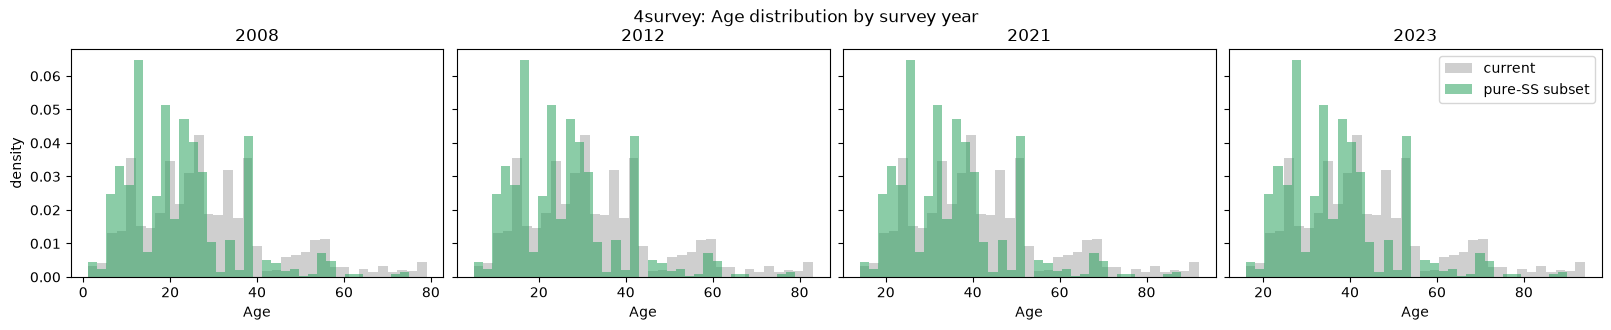

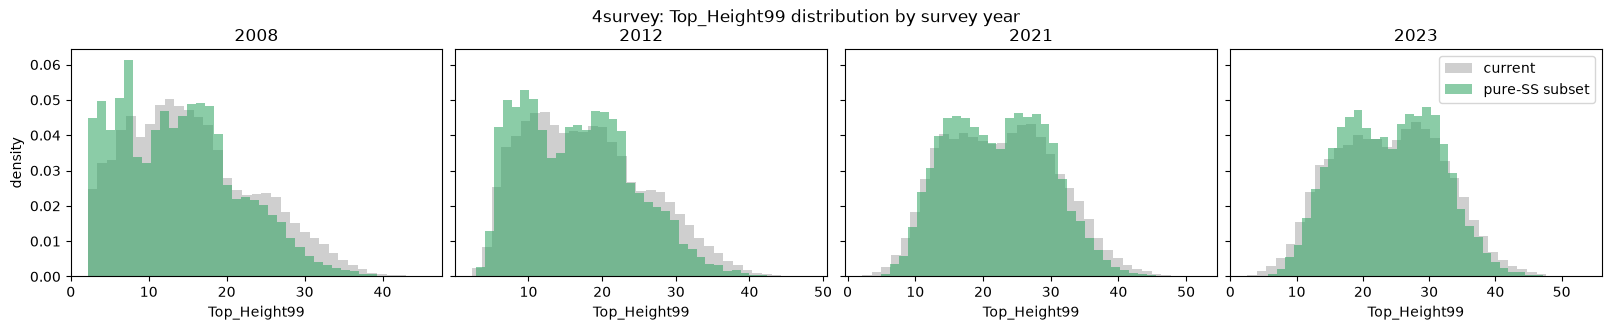

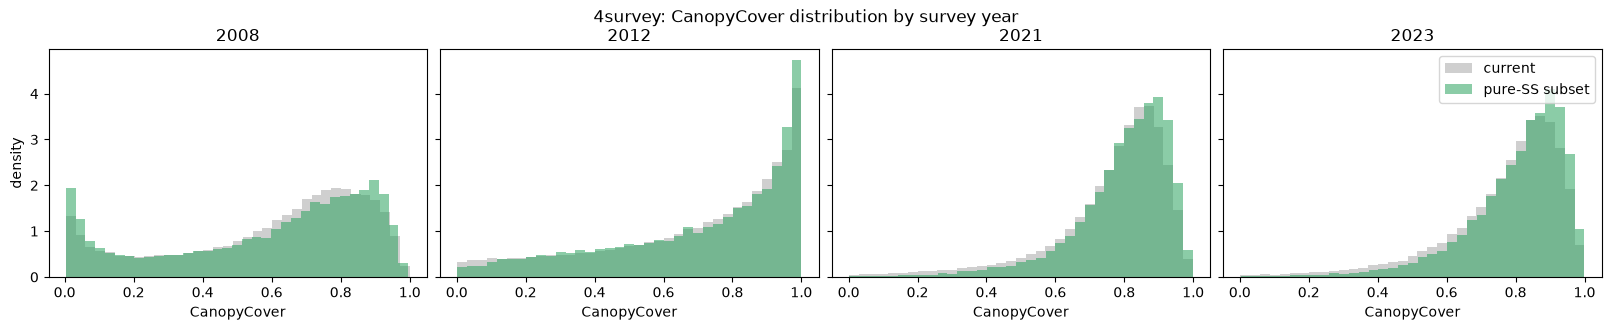

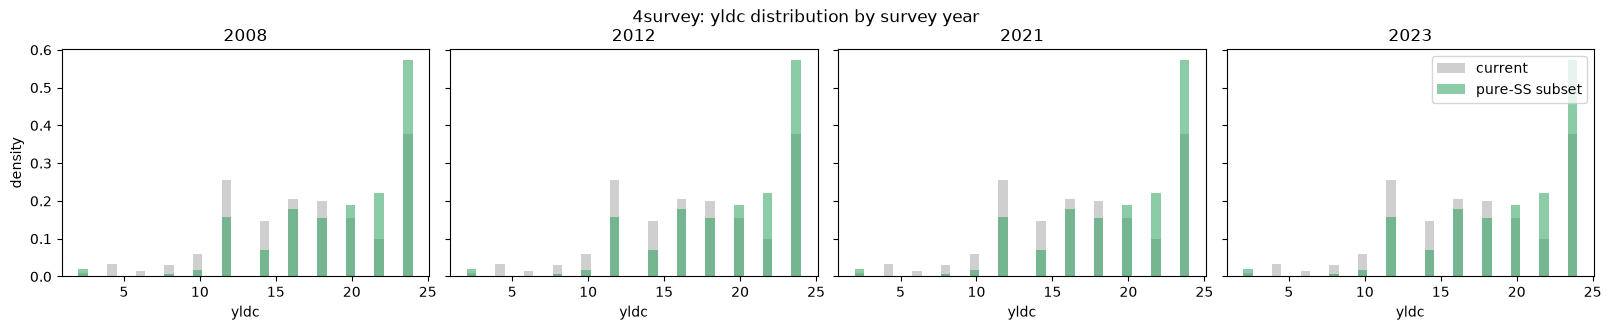

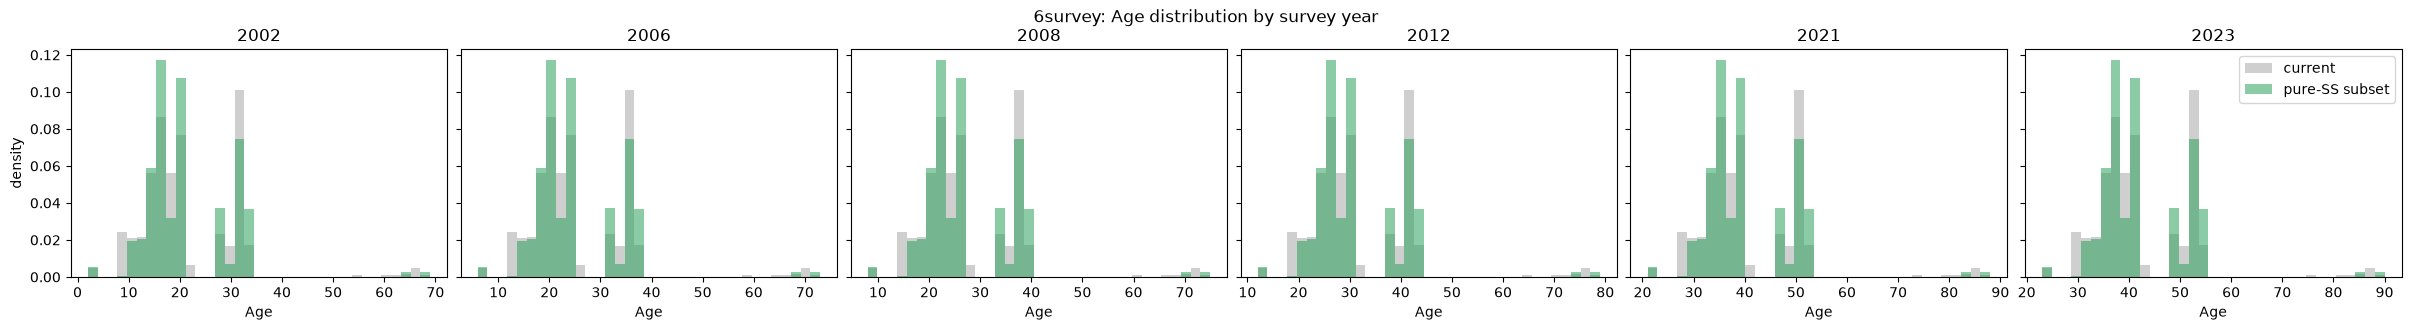

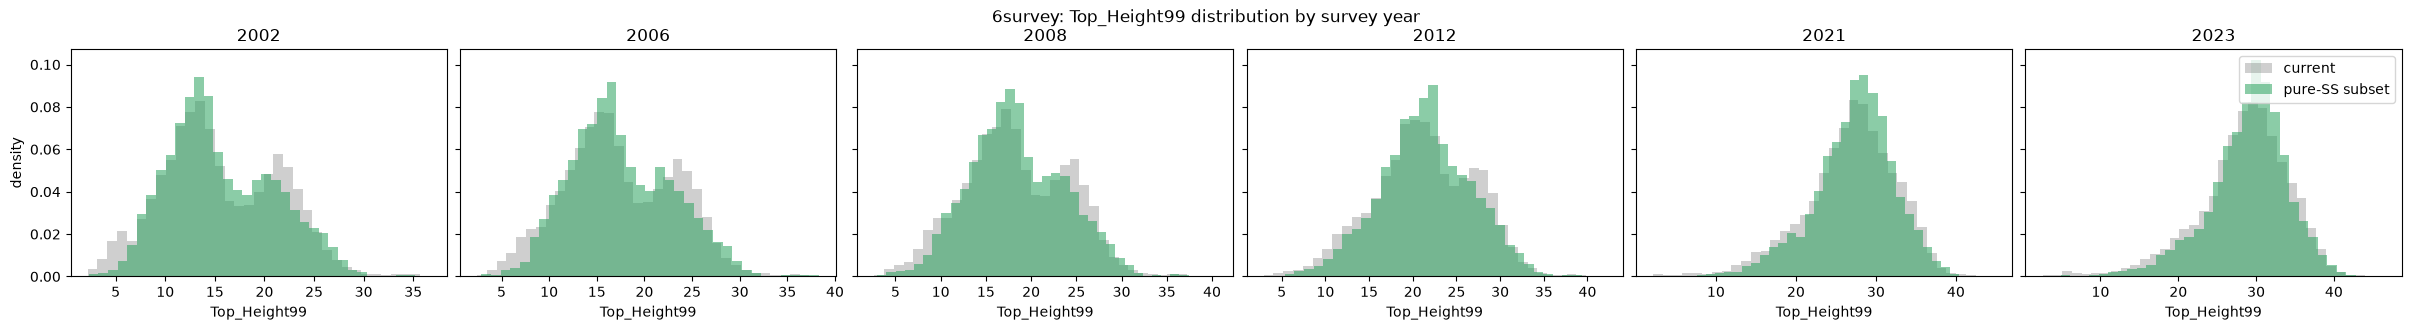

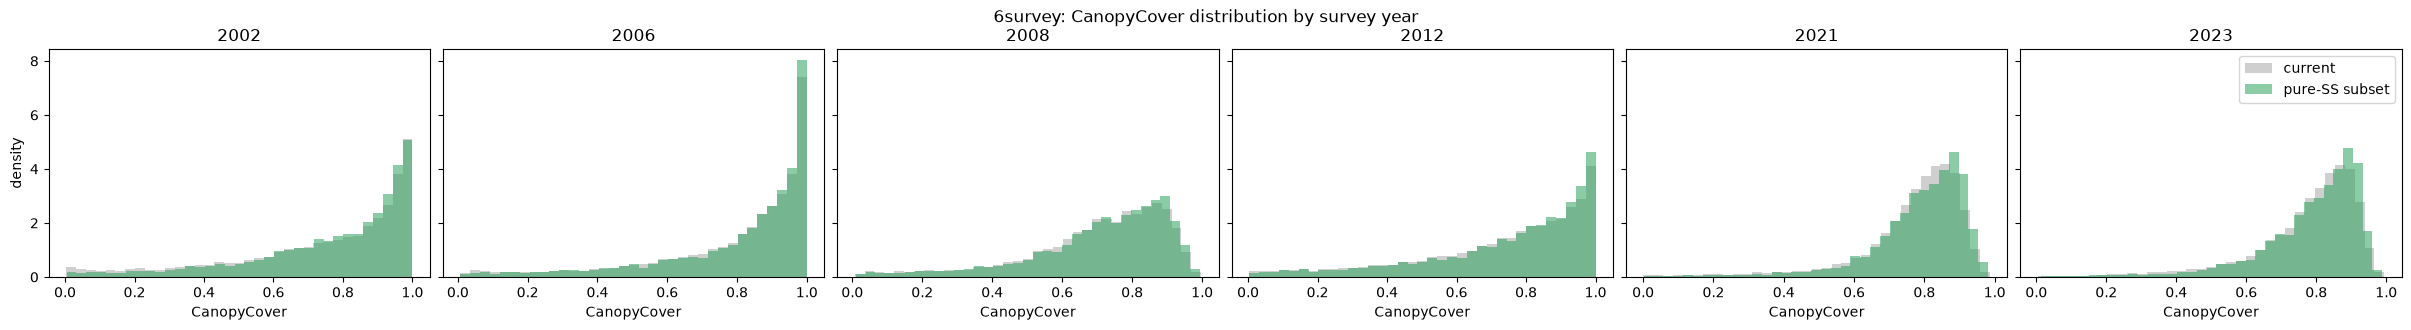

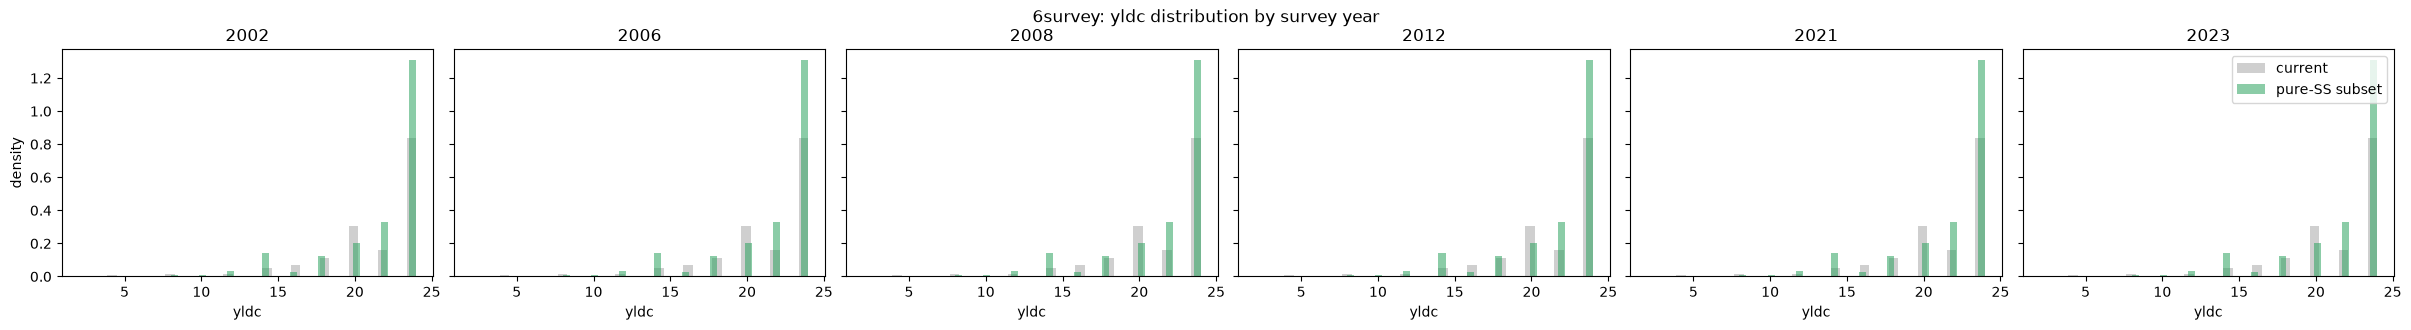

In [12]:
def plot_variable_distributions(flagged_df, cohort_name, variables=("Age", "Top_Height99", "CanopyCover", "yldc")):
    years = sorted(flagged_df["LiDAR_year"].unique())
    for var in variables:
        fig, axes = plt.subplots(1, len(years), figsize=(4 * len(years), 3), sharey=True, constrained_layout=True)
        if len(years) == 1:
            axes = [axes]
        for ax, year in zip(axes, years):
            group = flagged_df[flagged_df["LiDAR_year"].eq(year)]
            kept = group[group["in_pure_ss_layer"]]
            ax.hist(group[var].dropna(), bins=35, density=True, alpha=0.35, label="current", color="#777777")
            ax.hist(kept[var].dropna(), bins=35, density=True, alpha=0.55, label="pure-SS subset", color="#2ca25f")
            ax.set_title(str(year))
            ax.set_xlabel(var)
        axes[0].set_ylabel("density")
        axes[-1].legend(loc="upper right")
        fig.suptitle(f"{cohort_name}: {var} distribution by survey year", y=1.05)
        plt.show()

plot_variable_distributions(master_4_flagged, "4survey")
plot_variable_distributions(master_6_flagged, "6survey")

## Spatial comparison by survey year

Grey/green/red maps show current cleaned plots, pure-SS retained plots, and current plots that would be dropped by a pure-SS stand-key restriction.

These are point maps using the existing plot-coordinate table. They do not depend on reading the pure-SS shapefile geometry.

In [13]:
def add_plot_coordinates(df):
    coord_cols = coords[["identification", "x", "y"]].drop_duplicates("identification")
    return df.merge(coord_cols, on="identification", how="left")

master_4_xy = add_plot_coordinates(master_4_flagged)
master_6_xy = add_plot_coordinates(master_6_flagged)

print("4survey missing coordinates:", master_4_xy[["x", "y"]].isna().any(axis=1).sum())
print("6survey missing coordinates:", master_6_xy[["x", "y"]].isna().any(axis=1).sum())

4survey missing coordinates: 0
6survey missing coordinates: 0


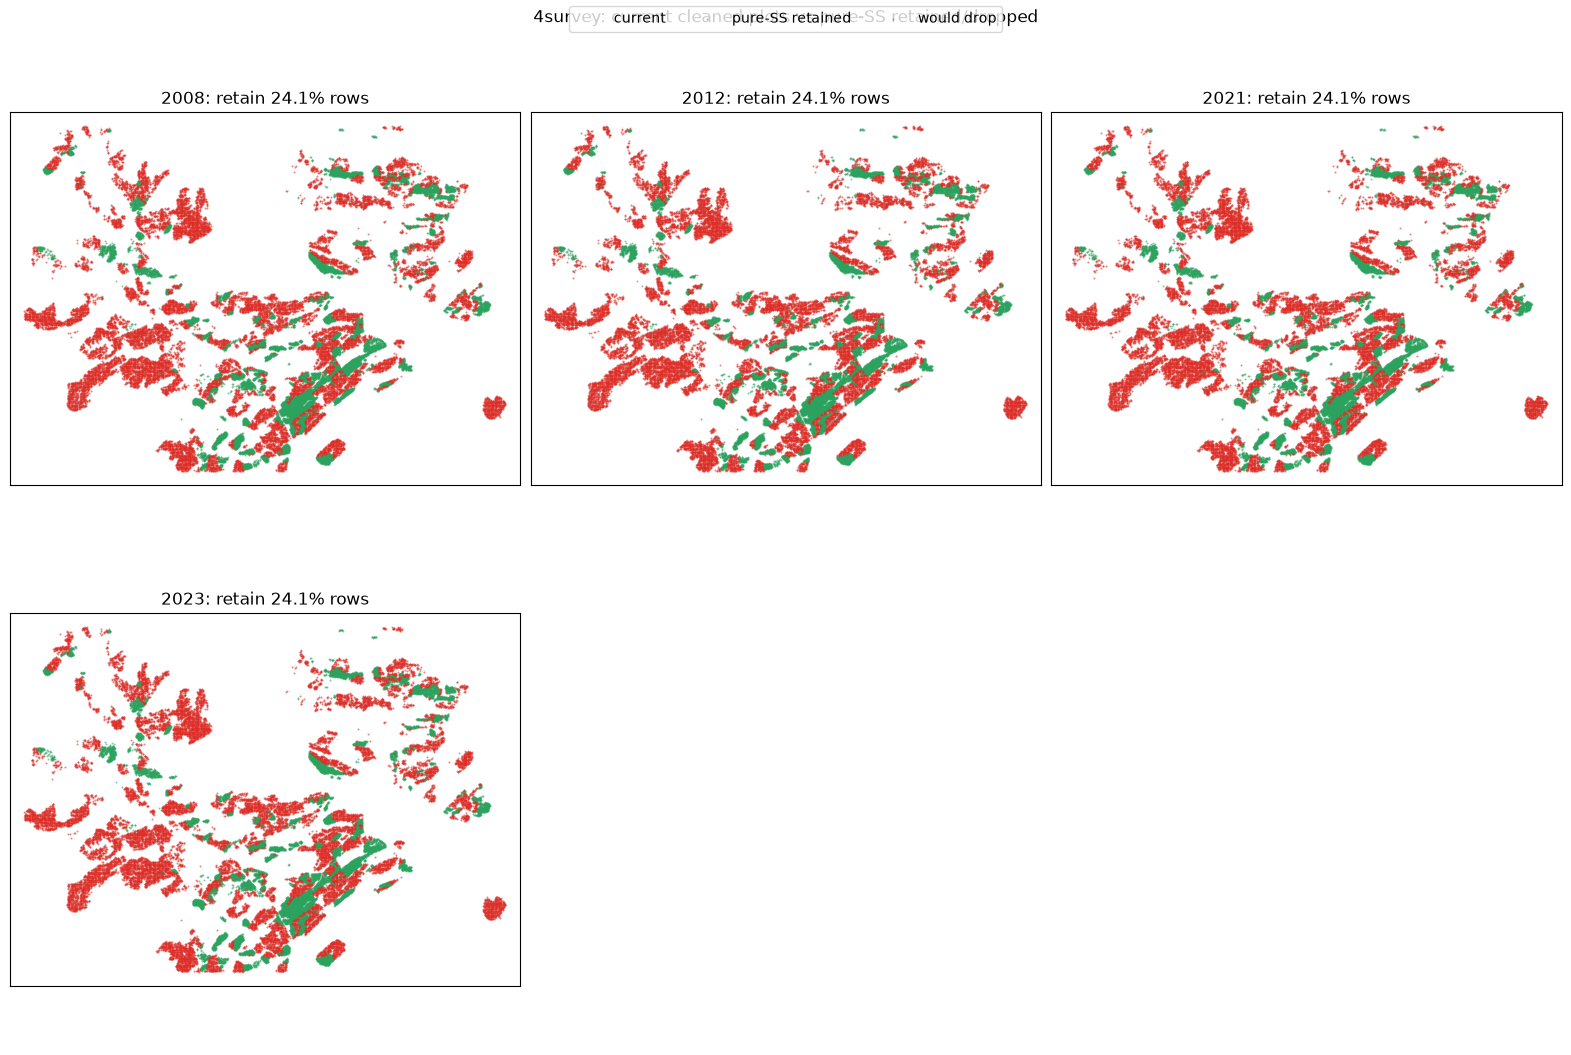

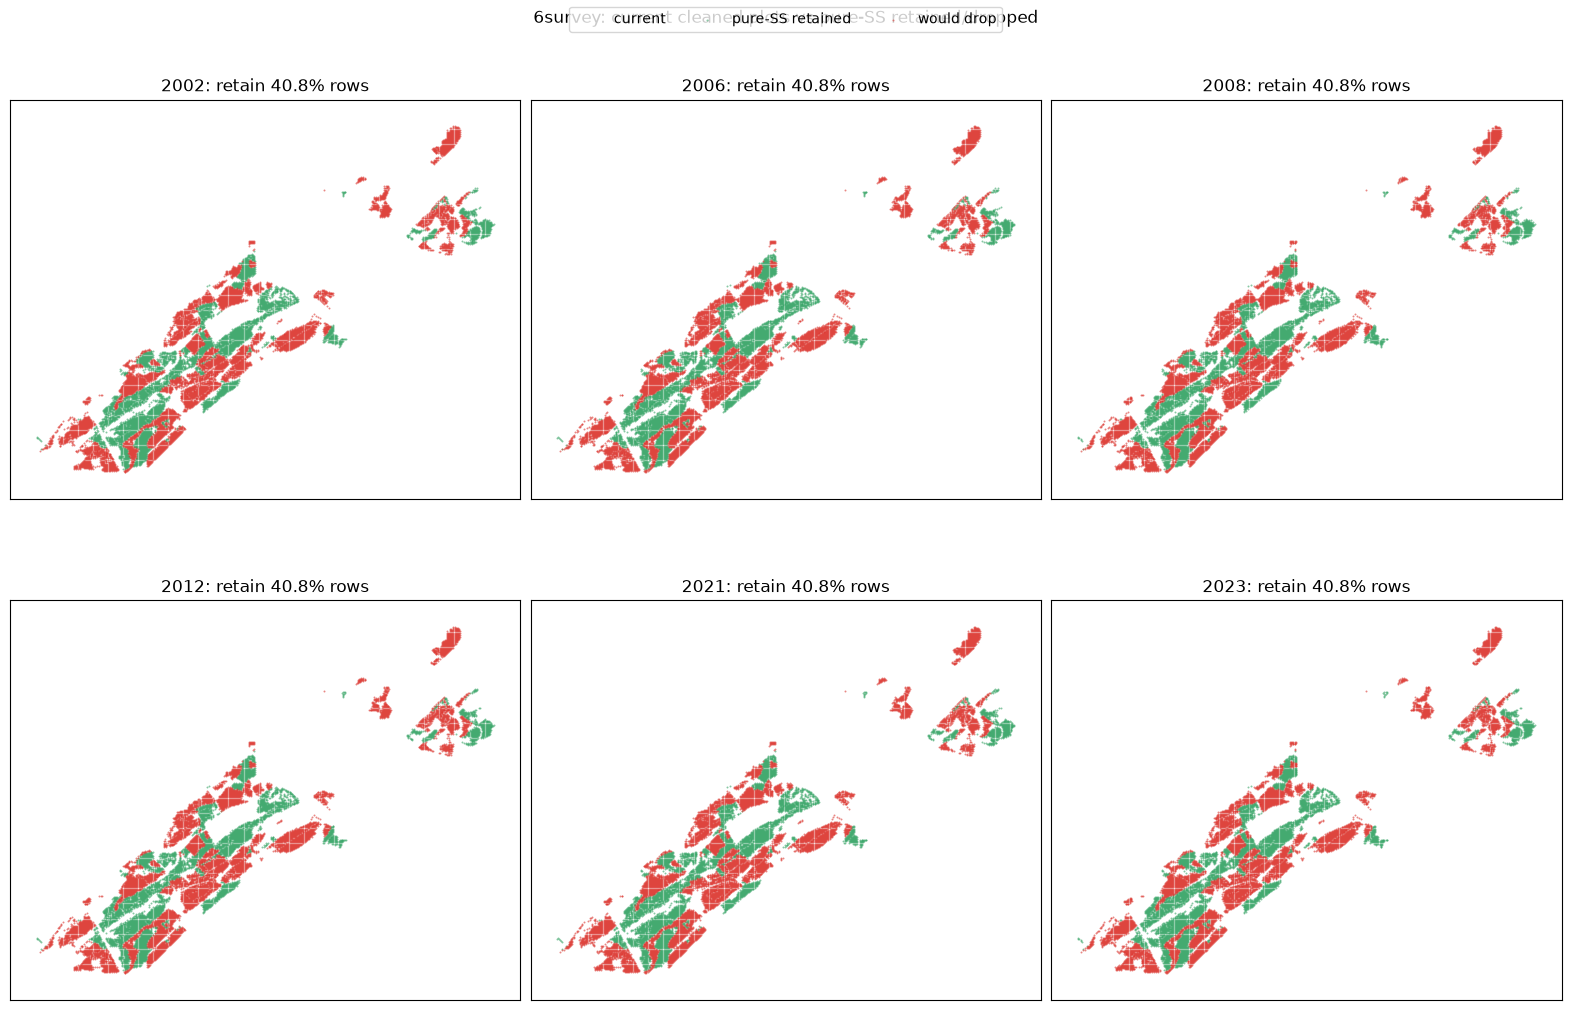

In [14]:
def sample_for_plot(df, max_points=25000, seed=42):
    if len(df) <= max_points:
        return df
    return df.sample(max_points, random_state=seed)


def plot_spatial_retention_by_year(df_xy, cohort_name):
    years = sorted(df_xy["LiDAR_year"].unique())
    ncols = min(3, len(years))
    nrows = int(np.ceil(len(years) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 5.0 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    xlim = (df_xy["x"].min() - 500, df_xy["x"].max() + 500)
    ylim = (df_xy["y"].min() - 500, df_xy["y"].max() + 500)

    for ax, year in zip(axes, years):
        group = df_xy[df_xy["LiDAR_year"].eq(year)].dropna(subset=["x", "y"])
        kept = sample_for_plot(group[group["in_pure_ss_layer"]])
        dropped = sample_for_plot(group[~group["in_pure_ss_layer"]])

        ax.scatter(group["x"], group["y"], s=1, color="#dddddd", alpha=0.25, linewidths=0, label="current")
        ax.scatter(kept["x"], kept["y"], s=2, color="#2ca25f", alpha=0.55, linewidths=0, label="pure-SS retained")
        ax.scatter(dropped["x"], dropped["y"], s=2, color="#de2d26", alpha=0.55, linewidths=0, label="would drop")
        ax.set_title(f"{year}: retain {100 * len(group[group['in_pure_ss_layer']]) / len(group):.1f}% rows")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(years):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3)
    fig.suptitle(f"{cohort_name}: current cleaned plots vs pure-SS retained/dropped", y=1.04)
    plt.show()

plot_spatial_retention_by_year(master_4_xy, "4survey")
plot_spatial_retention_by_year(master_6_xy, "6survey")

## Optional: try plotting pure-SS polygons

This cell is optional because shapefile readers can be fragile across environments. If it works, it gives a direct visual of the supplied pure-SS stand layer. If it fails, the core comparison above is still valid because it uses the DBF attributes.

In [15]:
RUN_OPTIONAL_GEOMETRY_PLOT = False

if RUN_OPTIONAL_GEOMETRY_PLOT:
    try:
        import geopandas as gpd

        pure_geo = gpd.read_file(PURE_SHP)
        print("pure geometry records:", len(pure_geo))
        print("CRS:", pure_geo.crs)
        ax = pure_geo.plot(figsize=(7, 7), facecolor="none", edgecolor="#2ca25f", linewidth=0.5)
        ax.set_title("Pure-SS stand polygons from scpt100")
        ax.set_aspect("equal", adjustable="box")
        plt.show()
    except Exception as exc:
        warnings.warn(f"Could not read/plot pure-SS shapefile geometry in this environment: {exc}")
else:
    print("Optional pure-SS polygon plot skipped. Set RUN_OPTIONAL_GEOMETRY_PLOT = True to try it.")

Optional pure-SS polygon plot skipped. Set RUN_OPTIONAL_GEOMETRY_PLOT = True to try it.


## Decision aid

This is a deliberately simple threshold summary. Use it to decide whether switching to the pure-SS layer would be a small sensitivity change or a major change to the dataset.

In [16]:
def decision_aid(overall_retention, shift_table, meta_diff_summary):
    min_plot_retention = overall_retention["plots_retained_pct"].min()
    max_abs_height_shift = (
        shift_table[shift_table["variable"].eq("Top_Height99")]["pure_minus_current_median"]
        .abs()
        .max()
    )
    yldc_diff = meta_diff_summary.loc[meta_diff_summary["column"].eq("yldc"), "different_pct_of_known"].iloc[0]

    print(f"Minimum plot retention across cohorts: {min_plot_retention:.1f}%")
    print(f"Maximum absolute median Top_Height99 shift by year/cohort: {max_abs_height_shift:.2f} m")
    print(f"Yield-class disagreement on overlapping stands: {yldc_diff:.1f}% of stands with both values")
    print()

    if min_plot_retention >= 90 and max_abs_height_shift < 0.5 and yldc_diff < 10:
        print("Interpretation: likely a small sensitivity restriction, not a dramatic population change.")
    elif min_plot_retention >= 75 and max_abs_height_shift < 1.0:
        print("Interpretation: moderate change. Probably worth reporting as a sensitivity caveat, but not automatically worth switching.")
    else:
        print("Interpretation: large change. Switching would materially alter the modelling population and should be treated as a new dataset version.")

decision_aid(overall_retention, shift_table, meta_diff_summary)

Minimum plot retention across cohorts: 24.1%
Maximum absolute median Top_Height99 shift by year/cohort: 1.10 m
Yield-class disagreement on overlapping stands: 0.0% of stands with both values

Interpretation: large change. Switching would materially alter the modelling population and should be treated as a new dataset version.
